### t-SNE — Réduction de dimensionnalité & Visualisation
- Dataset  : MNIST (10 000 échantillons)
- Algo     : t-SNE (sklearn)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


In [14]:
# DATASET
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

np.random.seed(42)
data = np.random.choice(len(X), 10000, replace=False)
X_sample = X[data]
y_sample = y[data]

print(f"Shape : {X_sample.shape} | Classes : {np.unique(y_sample)}\n")

X_sample = StandardScaler().fit_transform(X_sample)

Shape : (10000, 784) | Classes : [0 1 2 3 4 5 6 7 8 9]



In [19]:


print("Calcul t-SNE final sur 10 000 points...")
tsne_final = TSNE(
    n_components=2,
    perplexity=35,
    n_iter= 1000,
    random_state=42,
    verbose=1
)
X_2d = tsne_final.fit_transform(X_sample)

Calcul t-SNE final sur 10 000 points...
[t-SNE] Computing 106 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.014s...


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 2.287s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 5.848602
[t-SNE] KL divergence after 250 iterations with early exaggeration: 87.932617
[t-SNE] KL divergence after 1000 iterations: 1.714009


In [ ]:
# Evaluation
sub_idx = np.random.choice(len(X_2d), 3000, replace=False)
silhouette = silhouette_score(X_2d[sub_idx], y_sample[sub_idx])
davies     = davies_bouldin_score(X_2d, y_sample)
calinski   = calinski_harabasz_score(X_2d, y_sample)

print(f"\nSilhouette Score       : {silhouette:.4f}  ")
print(f"Davies-Bouldin Score   : {davies:.4f}  ")
print(f"Calinski-Harabasz Score: {calinski:.2f} ")
print("=" * 50)




Silhouette Score       : 0.1878  (↑ meilleur, max=1)
Davies-Bouldin Score   : 4.6480  (↓ meilleur, min=0)
Calinski-Harabasz Score: 3319.20 (↑ meilleur)


(np.float64(-87.67109603881836),
 np.float64(101.07784957885742),
 np.float64(-84.9088523864746),
 np.float64(83.6866081237793))

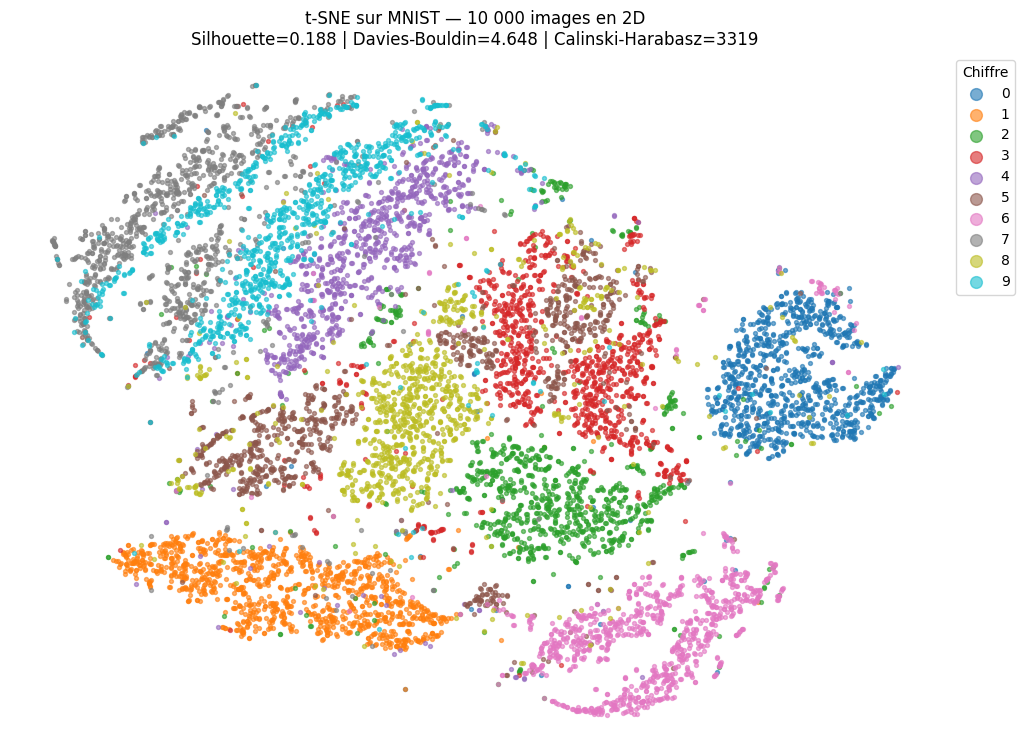

In [23]:
# VISUALISATION
colors = plt.cm.tab10(np.linspace(0, 1, 10))

plt.figure(figsize=(12, 9))
for digit in range(10):
    mask = y_sample == digit
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=[colors[digit]], label=str(digit),
        s=8, alpha=0.6
    )

plt.title(
    f"t-SNE sur MNIST — 10 000 images en 2D\n"
    f"Silhouette={silhouette:.3f} | Davies-Bouldin={davies:.3f} | Calinski-Harabasz={calinski:.0f}",
    fontsize=12
)
plt.legend(title="Chiffre", markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.axis('off')